In [34]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

I suspect i need to combine all the files into one, create new files for each site using a nearest match to the lat and lon and then download those individually. In the future I can probably do this on Trillium OpenOnDemand or something like that

In [35]:
ds = xr.open_dataset("0.1deg_sp_transient.clm2.h0.2014-12.nc")

C:\Users\madel\AppData\Local\Temp\ipykernel_21208\664643038.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("0.1deg_sp_transient.clm2.h0.2014-12.nc")


In [36]:
ds

<xarray.Dataset> Size: 180MB
Dimensions:                        (time: 1, hist_interval: 2, lat: 221,
                                    lon: 421, cft: 64, glc_nec: 10,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    ltype: 9, natpft: 15, nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 8B 2015-01-01 00:00:00
  * lat                            (lat) float32 884B 50.05 50.15 ... 71.95
  * lon                            (lon) float32 2kB 217.0 217.1 ... 258.9 259.0
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, cft, glc_nec, ltype, natpft,
                                nvegwcs
Data variables: (12/247)
    mcdate                         (time) int32 4B ...
    mcsec                          (time) int32 4B ...
    mdcur                          (time) int32 4B ...
    mscur                          (time) int32 4B ...
    nstep                          (time) int32 4B ...
    time_bounds                    (time, hist_interval) object 16B ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lat, lon) float32 7MB ...
    PCT_LANDUNIT                   (time, ltype, lat, lon) float32 3MB ...
    PCT_NAT_PFT                    (time, natpft, lat, lon) float32 6MB ...
    VEGWP                          (time, nvegwcs, lat, lon) float32 1MB ...
    VEGWPLN                        (time, nvegwcs, lat, lon) float32 1MB ...
    VEGWPPD                        (time, nvegwcs, lat, lon) float32 1MB ...
Attributes: (12/101)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              created on 05/16/26 23:49:21
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     month_1
    Time_constant_3Dvars_filename:        ./0.1deg_sp_transient.clm2.h0.2001-...
    Time_constant_3Dvars:                 ZSOI:DZSOI:WATSAT:SUCSAT:BSW:HKSAT:...

In [37]:
ds_TSOI= ds["TSOI"]

In [38]:
ds_TSOI

<xarray.DataArray 'TSOI' (time: 1, levgrnd: 25, lat: 221, lon: 421)> Size: 9MB
[2326025 values with dtype=float32]
Coordinates:
  * time     (time) object 8B 2015-01-01 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
  * lat      (lat) float32 884B 50.05 50.15 50.25 50.35 ... 71.75 71.85 71.95
  * lon      (lon) float32 2kB 217.0 217.1 217.2 217.3 ... 258.8 258.9 259.0
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [39]:
TVC_10km = ds_TSOI.sel(lat=68.7462, lon=-133.5017 % 360, method="nearest")
TVC_10km

<xarray.DataArray 'TSOI' (time: 1, levgrnd: 25)> Size: 100B
[25 values with dtype=float32]
Coordinates:
  * time     (time) object 8B 2015-01-01 00:00:00
  * levgrnd  (levgrnd) float32 100B 0.01 0.04 0.09 0.16 ... 19.48 28.87 42.0
    lon      float32 4B 226.5
    lat      float32 4B 68.76
Attributes:
    long_name:      soil temperature (natural vegetated and crop landunits only)
    units:          K
    cell_methods:   time: mean
    landunit_mask:  veg

In [ ]:
"""
Visualise how CTSM/CLM has partitioned a domain into gridcells, and where
sites of interest fall within that tessellation.

Works with CTSM history files (h0/h1) and surface datasets read via xarray.
Handles regular lat/lon grids (1D lat/lon), surface-dataset style 2D
LONGXY/LATIXY, and 1D unstructured/vector output as a fallback.

Requires: xarray, numpy, matplotlib (cartopy optional).
"""

from __future__ import annotations

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# coordinate helpers
# ----------------------------------------------------------------------

_LAT_NAMES = ("lat", "latitude", "lsmlat", "LATIXY")
_LON_NAMES = ("lon", "longitude", "lsmlon", "LONGXY")

# CLM5 natpft order (index -> plant functional type)
NATPFT_NAMES = [
    "bare soil",
    "needleleaf evergreen temperate tree",
    "needleleaf evergreen boreal tree",
    "needleleaf deciduous boreal tree",
    "broadleaf evergreen tropical tree",
    "broadleaf evergreen temperate tree",
    "broadleaf deciduous tropical tree",
    "broadleaf deciduous temperate tree",
    "broadleaf deciduous boreal tree",
    "broadleaf evergreen shrub",
    "broadleaf deciduous temperate shrub",
    "broadleaf deciduous boreal shrub",
    "c3 arctic grass",
    "c3 non-arctic grass",
    "c4 grass",
]


def _first_present(ds, names):
    for n in names:
        if n in ds.variables or n in ds.coords:
            return n
    return None


def _edges_from_centers(c):
    """Cell edges (n+1) from cell centres (n), extrapolating at the ends."""
    c = np.asarray(c, dtype=float)
    if c.size < 2:
        raise ValueError("need at least 2 cell centres to infer edges")
    mid = 0.5 * (c[:-1] + c[1:])
    first = c[0] - (mid[0] - c[0])
    last = c[-1] + (c[-1] - mid[-1])
    return np.concatenate([[first], mid, [last]])


def _edges(ds, name):
    """Prefer explicit bounds variables; otherwise infer from centres."""
    for b in (f"{name}_bnds", f"{name}_bounds", f"{name}b", f"{name}_vertices"):
        if b in ds.variables:
            arr = np.asarray(ds[b].values, dtype=float)
            if arr.ndim == 2 and arr.shape[1] == 2:
                return np.concatenate([arr[:, 0], arr[-1:, 1]])
    return _edges_from_centers(np.asarray(ds[name].values, dtype=float))


def get_grid(ds):
    """
    Return (lat_centers, lon_centers, lat_edges, lon_edges, kind).

    kind is 'rectilinear' for a proper lat x lon mesh, or 'vector' when the
    file only carries a 1D list of gridcell centres (SE/unstructured output),
    in which case the edge arrays are None.
    """
    latn = _first_present(ds, _LAT_NAMES)
    lonn = _first_present(ds, _LON_NAMES)
    if latn is None or lonn is None:
        raise KeyError(f"no lat/lon found; variables are {list(ds.variables)[:20]}...")

    lat = np.asarray(ds[latn].values, dtype=float)
    lon = np.asarray(ds[lonn].values, dtype=float)

    # surface-dataset style: 2D LATIXY/LONGXY on a regular grid
    if lat.ndim == 2 and lon.ndim == 2:
        lat1d, lon1d = lat[:, 0], lon[0, :]
        return lat1d, lon1d, _edges_from_centers(lat1d), _edges_from_centers(lon1d), "rectilinear"

    # 1D coords that index their own dimension -> rectilinear
    if lat.ndim == 1 and lon.ndim == 1:
        same_dim = (
            ds[latn].dims == ds[lonn].dims and len(ds[latn].dims) == 1
        )
        if same_dim:  # both indexed by 'gridcell' -> unstructured vector
            return lat, lon, None, None, "vector"
        return lat, lon, _edges(ds, latn), _edges(ds, lonn), "rectilinear"

    raise ValueError("unrecognised lat/lon layout")


def _match_lon(lon, lon_ref):
    """Put site longitudes into the same convention as the dataset."""
    lon = np.asarray(lon, dtype=float)
    if np.nanmax(lon_ref) > 180.0:          # dataset uses 0-360
        return np.where(lon < 0, lon + 360.0, lon)
    return np.where(lon > 180.0, lon - 360.0, lon)  # dataset uses -180-180


# ----------------------------------------------------------------------
# site lookup
# ----------------------------------------------------------------------

def locate_sites(ds, sites):
    """
    For each site, find the CTSM gridcell that contains it.

    sites : dict {name: (lat, lon)}  -- lon in either convention

    Returns a list of dicts with the index (or indices), the cell centre,
    and the offset between site and cell centre in degrees.
    """
    lat_c, lon_c, lat_e, lon_e, kind = get_grid(ds)
    out = []

    for name, (slat, slon) in sites.items():
        slon_m = float(_match_lon([slon], lon_c)[0])

        if kind == "rectilinear":
            j = int(np.clip(np.searchsorted(lat_e, slat) - 1, 0, len(lat_c) - 1))
            i = int(np.clip(np.searchsorted(lon_e, slon_m) - 1, 0, len(lon_c) - 1))
            rec = dict(site=name, lat=slat, lon=slon_m,
                       ilat=j, ilon=i,
                       cell_lat=float(lat_c[j]), cell_lon=float(lon_c[i]))
        else:
            d = (lat_c - slat) ** 2 + (lon_c - slon_m) ** 2
            k = int(np.argmin(d))
            rec = dict(site=name, lat=slat, lon=slon_m, igridcell=k,
                       cell_lat=float(lat_c[k]), cell_lon=float(lon_c[k]))

        rec["dlat"] = rec["cell_lat"] - slat
        rec["dlon"] = rec["cell_lon"] - slon_m
        out.append(rec)

    return out


# ----------------------------------------------------------------------
# per-site variable printout (used instead of shading the map)
# ----------------------------------------------------------------------

def print_site_variable(ds, records, var, isel=None, names=None, threshold=0.0, label=None):
    """
    Print the value(s) of `var` at each site's gridcell, without touching
    the plot. Handy for variables like PCT_NAT_PFT that carry an extra
    non-spatial dimension (natpft) and don't shade onto a 2D map cleanly.

    ds      : the Dataset that `var` lives in
    records : output of locate_sites(), so each site is looked up by its
              actual gridcell index rather than by nearest coordinate again
    isel    : dict passed to ds[var].isel() first, e.g. {'time': 0}
    names   : optional labels for the variable's leading non-spatial
              dimension (e.g. NATPFT_NAMES for PCT_NAT_PFT); defaults to
              plain indices
    threshold : only print entries whose value exceeds this (default 0)
    label   : optional heading (e.g. a resolution) printed above this
              dataset's block, so output from multiple grids is easy to
              tell apart
    """
    da = ds[var]
    if isel:
        da = da.isel(**isel)

    if label:
        print(f"\n=== {label} ===")

    for r in records:
        if "ilat" not in r:
            raise ValueError(
                "print_site_variable currently only supports rectilinear "
                "(lat/lon indexed) grids"
            )
        cell = da.isel(lat=r["ilat"], lon=r["ilon"])
        values = np.atleast_1d(np.asarray(cell.values))

        print(f"\n{r['site']} (cell {r['cell_lat']:.3f}, {r['cell_lon']:.3f}):")
        if values.size == 1:
            print(f"  {var} = {values.item():.3g}")
        else:
            pft_labels = names if names is not None else [str(i) for i in range(values.size)]
            for pft_label, v in zip(pft_labels, values):
                if v > threshold:
                    print(f"  {pft_label:40s} {v:6.2f}")


# ----------------------------------------------------------------------
# main plot
# ----------------------------------------------------------------------

def plot_ctsm_grid(
    ds,
    sites=None,
    var=None,
    isel=None,
    other=None,
    extent=None,
    ax=None,
    grid_color="0.35",
    other_color="crimson",
    cmap="viridis",
    label_sites=True,
    coastlines=True,
    figsize=(9, 7),
    print_var=None,
    print_isel=None,
    print_names=None,
    print_threshold=0.0,
    print_other=True,
):
    """
    Draw the CTSM gridcell tessellation with sites of interest on top.

    ds     : xarray.Dataset -- the CTSM file whose grid defines the mesh
    sites  : dict {name: (lat, lon)}
    var    : optional variable name in ds to shade underneath the mesh
             (e.g. 'RAIN', 'TOTVEGC', 'PCT_NATVEG'); must reduce to 2D
             (lat, lon) after isel -- not suitable for PFT-resolved
             variables like PCT_NAT_PFT, use print_var for those instead
    isel   : dict passed to ds[var].isel() to reduce extra dims,
             e.g. {'time': 0} or {'time': 0, 'natpft': 1}
    other  : optional second Dataset at a different resolution; its cell
             edges are drawn over the top so you can see how the two
             tessellations line up
    extent : (lon_min, lon_max, lat_min, lat_max) to zoom, in the same
             convention as the dataset or -180..180 (converted for you)
    print_var, print_isel, print_names, print_threshold :
             instead of (or as well as) shading, print this variable's
             value(s) at each site's gridcell to stdout -- nothing about
             it is drawn on the map. See print_site_variable().
    print_other : when print_var is set and `other` is provided, also
             print print_var looked up in `other` at each site (using
             other's own gridcell), so the two resolutions can be
             compared side by side. Set False to only print from `ds`.

    Returns (fig, ax, site_records).
    """
    lat_c, lon_c, lat_e, lon_e, kind = get_grid(ds)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    def _clip(edges, axis):
        """Only draw the lines that fall inside the view (keeps global
        0.25-degree files from drawing thousands of invisible lines)."""
        if extent is None or edges is None:
            return edges
        x0, x1, y0, y1 = extent
        lo, hi = sorted(_match_lon([x0, x1], lon_c)) if axis == "x" else (y0, y1)
        pad = np.abs(np.diff(edges)).mean()
        return edges[(edges >= lo - pad) & (edges <= hi + pad)]

    # ---- shaded field -------------------------------------------------
    if var is not None:
        da = ds[var]
        if isel:
            da = da.isel(**isel)
        da = da.squeeze()
        if da.ndim != 2:
            raise ValueError(
                f"{var} has dims {da.dims} after isel; reduce it to 2D "
                "(e.g. isel={'time': 0}), or use print_var= instead if it "
                "carries a PFT/landunit dimension that shouldn't be shaded"
            )
        if kind == "rectilinear":
            mesh = ax.pcolormesh(lon_e, lat_e, np.asarray(da.values),
                                 cmap=cmap, shading="flat", alpha=0.85)
            fig.colorbar(mesh, ax=ax, shrink=0.8,
                         label=f"{var} [{da.attrs.get('units', '')}]")

    # ---- the grid itself ----------------------------------------------
    if kind == "rectilinear":
        for x in _clip(lon_e, "x"):
            ax.axvline(x, color=grid_color, lw=0.6, zorder=3)
        for y in _clip(lat_e, "y"):
            ax.axhline(y, color=grid_color, lw=0.6, zorder=3)
        # cell centres: what the model actually reports a value "at"
        LON, LAT = np.meshgrid(lon_c, lat_c)
        ax.plot(LON.ravel(), LAT.ravel(), ".", ms=2.0,
                color=grid_color, zorder=4, label="gridcell centre")
        res = f"{np.abs(np.diff(lat_c)).mean():.3f}° x {np.abs(np.diff(lon_c)).mean():.3f}°"
    else:
        ax.plot(lon_c, lat_c, ".", ms=3, color=grid_color, zorder=4,
                label="gridcell centre")
        res = "unstructured"

    # ---- second grid ---------------------------------------------------
    if other is not None:
        olat_c, olon_c, olat_e, olon_e, okind = get_grid(other)
        if okind == "rectilinear":
            for x in _clip(olon_e, "x"):
                ax.axvline(x, color=other_color, lw=0.6, ls="--", zorder=3)
            for y in _clip(olat_e, "y"):
                ax.axhline(y, color=other_color, lw=0.6, ls="--", zorder=3)
            ores = (f"{np.abs(np.diff(olat_c)).mean():.3f}° x "
                    f"{np.abs(np.diff(olon_c)).mean():.3f}°")
        else:
            ax.plot(olon_c, olat_c, "x", ms=4, color=other_color, zorder=4)
            ores = "unstructured"
        ax.plot([], [], color=other_color, ls="--", lw=0.8,
                label=f"grid B ({ores})")

    ax.plot([], [], color=grid_color, lw=0.8, label=f"grid A ({res})")

    # ---- sites ----------------------------------------------------------
    records = []
    if sites:
        records = locate_sites(ds, sites)
        for r in records:
            ax.plot(r["lon"], r["lat"], "*", ms=15, mec="k", mew=0.6,
                    color="gold", zorder=6)
            ax.plot([r["lon"], r["cell_lon"]], [r["lat"], r["cell_lat"]],
                    "-", color="k", lw=0.7, zorder=5)
            if label_sites:
                ax.annotate(r["site"], (r["lon"], r["lat"]),
                            textcoords="offset points", xytext=(7, 5),
                            fontsize=9, zorder=7,
                            bbox=dict(fc="white", ec="none", alpha=0.7, pad=1.2))
        ax.plot([], [], "*", ms=10, color="gold", mec="k", label="site")

        if print_var is not None:
            print_site_variable(ds, records, print_var, isel=print_isel,
                                 names=print_names, threshold=print_threshold,
                                 label=f"grid A ({res})")
            if other is not None and print_other:
                other_records = locate_sites(other, sites)
                print_site_variable(other, other_records, print_var, isel=print_isel,
                                     names=print_names, threshold=print_threshold,
                                     label=f"grid B ({ores})")

    # ---- framing ---------------------------------------------------------
    if extent is not None:
        x0, x1, y0, y1 = extent
        x0, x1 = _match_lon([x0, x1], lon_c)
        ax.set_xlim(sorted([x0, x1]))
        ax.set_ylim(y0, y1)

    if coastlines:
        _try_coastlines(ax)

    mid_lat = np.mean(ax.get_ylim())
    ax.set_aspect(1.0 / max(np.cos(np.deg2rad(mid_lat)), 0.05))
    ax.set_xlabel("longitude (°E)")
    ax.set_ylabel("latitude (°N)")
    ax.set_title("CTSM gridcell partitioning")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)

    return fig, ax, records


def _try_coastlines(ax):
    """Draw coastlines if cartopy is installed; silently skip if not."""
    try:
        import cartopy.feature as cfeature
        from cartopy.mpl.geoaxes import GeoAxes
        if isinstance(ax, GeoAxes):
            ax.coastlines(resolution="50m", lw=0.7)
            ax.add_feature(cfeature.BORDERS, lw=0.4)
    except Exception:
        pass



C:\Users\madel\AppData\Local\Temp\ipykernel_21208\417127860.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  coarse = xr.open_dataset("0.1deg_sp_transient.clm2.h0.2014-12.nc")
C:\Users\madel\AppData\Local\Temp\ipykernel_21208\417127860.py:2: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a 


TVC (cell 68.765, 226.527):
  bare soil                                  3.03
  needleleaf evergreen boreal tree           2.26
  needleleaf deciduous boreal tree           0.07
  broadleaf deciduous boreal tree            0.67
  broadleaf deciduous boreal shrub          53.00
  c3 arctic grass                           40.97

HC (cell 68.367, 226.527):
  bare soil                                  0.55
  needleleaf evergreen boreal tree           9.25
  needleleaf deciduous boreal tree           0.97
  broadleaf deciduous boreal tree            0.95
  broadleaf deciduous boreal shrub          55.47
  c3 arctic grass                           32.80


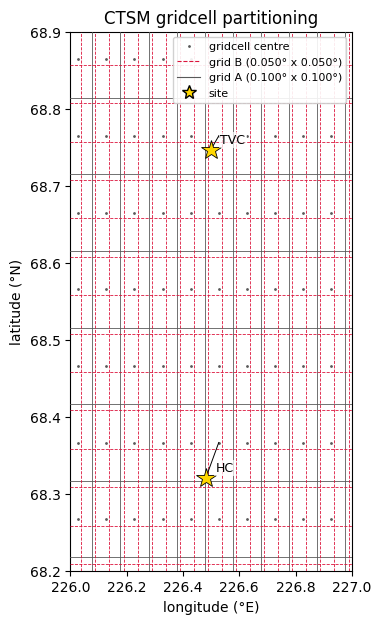

In [41]:
coarse = xr.open_dataset("0.1deg_sp_transient.clm2.h0.2014-12.nc")
fine   = xr.open_dataset("0.05deg_sp_transient.clm2.h0.2014-12.nc")

sites = {"TVC": (68.7462, -133.5017), "HC": (68.3203, -133.5188)}

fig, ax, recs = plot_ctsm_grid(
    coarse, sites=sites,
    other=fine, extent=(-134, -133, 68.2, 68.9),
    print_var="PCT_NAT_PFT", print_isel={"time": 0}, print_names=NATPFT_NAMES,
)